In [1]:
# ============================================================
# Notebook 01 — Data Collection
# CO₂: NOAA Global Monitoring Laboratory
# NDVI + SST: Google Earth Engine (exported separately)
# Author: Nihaar Raut | 001309432
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from pathlib import Path

# Define data paths
RAW_DATA = Path('../data/raw')
RAW_DATA.mkdir(parents=True, exist_ok=True)

print("Libraries loaded successfully")
print(f"Raw data path: {RAW_DATA.resolve()}")

Libraries loaded successfully
Raw data path: C:\Users\NIHAAR\Desktop\fyp-environmental-forecasting\data\raw


In [4]:
# ============================================================
# CO₂ Data Download — NOAA Global Monitoring Laboratory
# Global Monthly Mean CO₂ (ppm), 2000-2024
# Source: https://gml.noaa.gov/ccgg/trends/global.html
# ============================================================

url = "https://gml.noaa.gov/webdata/ccgg/trends/co2/co2_mm_gl.csv"

co2_raw = pd.read_csv(url, comment='#')
co2_raw.columns = co2_raw.columns.str.strip()

# Build date column
co2_raw['date'] = pd.to_datetime(
    co2_raw[['year', 'month']].assign(day=1)
)

# Rename average to co2_mean for consistency
co2_raw = co2_raw.rename(columns={'average': 'co2_mean'})

# Filter to study period
co2 = co2_raw[['date', 'co2_mean']].copy()
co2 = co2[(co2['date'] >= '2000-01-01') & 
          (co2['date'] <= '2024-12-31')]
co2.reset_index(drop=True, inplace=True)

# Save
co2.to_csv(RAW_DATA / 'co2_monthly_global.csv', index=False)

print(f"Records: {len(co2)}")
print(f"Date range: {co2['date'].min()} to {co2['date'].max()}")
print(f"CO₂ range: {co2['co2_mean'].min():.2f} to {co2['co2_mean'].max():.2f} ppm")
print(f"Missing values: {co2['co2_mean'].isna().sum()}")
print("\nFirst 3 rows:")
print(co2.head(3))

Records: 300
Date range: 2000-01-01 00:00:00 to 2024-12-01 00:00:00
CO₂ range: 366.71 to 425.19 ppm
Missing values: 0

First 3 rows:
        date  co2_mean
0 2000-01-01    369.39
1 2000-02-01    369.65
2 2000-03-01    369.97


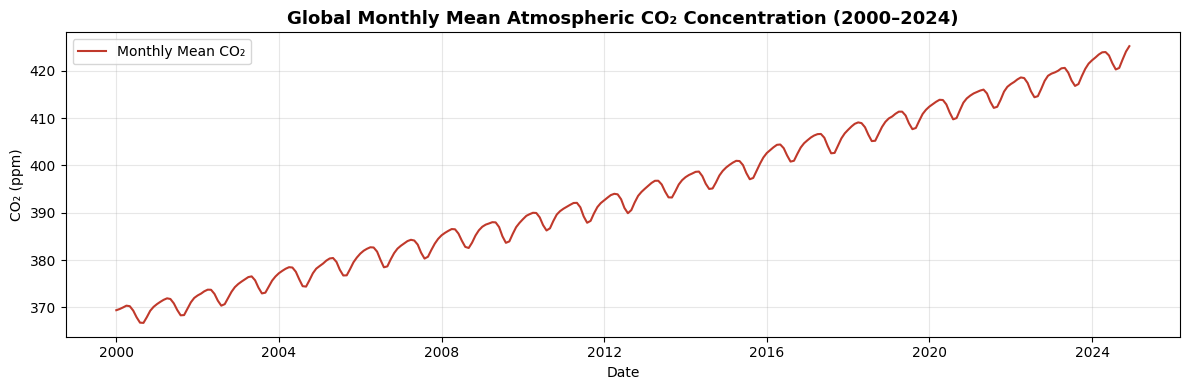

Figure saved to outputs/figures/


In [5]:
# ============================================================
# Figure 01 — Global Monthly Mean CO₂ (2000-2024)
# ============================================================

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(co2['date'], co2['co2_mean'], 
        color='#c0392b', linewidth=1.5, label='Monthly Mean CO₂')

ax.set_title('Global Monthly Mean Atmospheric CO₂ Concentration (2000–2024)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('CO₂ (ppm)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/fig01_co2_monthly.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved to outputs/figures/")